# 03. Modeling — 학습, 평가, 논문 대비 GAP, 오류 분석

실험은 `src/train.py` 한 번 실행으로 재현되며(약 30초), 결과 표는 모두 `results/`에 저장됩니다. 이 노트북은 그 결과를 읽어 해석하고 그림을 만듭니다.

**과제 기준**(학습 Batch 1, 평가 Batch 2, Regression, 논문 대비 GAP) 안에서 **DAY 1 보고서의 모델 설계 전략 §3**을 따릅니다.

| 보고서 전략 | 구현 |
|---|---|
| 후보: 학습 셀 수명 중앙값 상수 기준선, `ln_dq_variance` 단일 피처 Linear Regression | `Baseline (train median)`, `Linear (ln Var ΔQ)` |
| 확장 피처에는 Ridge로 남은 상관을 규제 | `Ridge (extended)`, 피처 그룹은 Batch 1 CV 오차를 줄일 때만 하나씩 채택(전진 선택) |
| Random Forest로 비선형 이득 확인, 최대 깊이·최소 리프 제한 | `max_depth=3`, `min_samples_leaf=3`, 전체 후보 피처 |
| 원래 `cycle_life`와 `log(cycle_life)` 학습을 CV로 비교, 오차는 사이클 단위로 계산 | 모델마다 두 target을 비교해 Batch 1 CV RMSE가 낮은 쪽 사용 |
| 배치별 검증 오차가 줄지 않으면 더 단순한 모델 선택 | Linear에서 출발해, 더 복잡한 모델이 **Batch 3 검증 RMSE**를 낮출 때만 교체 |
| 한 배치를 통째로 제외한 평가 | leave-one-batch-out 3회 |
| MAE·RMSE·MAPE, 배치별 오차, 단·장수명 구간 잔차 | 아래 표·그림 |

| 데이터 | 역할 |
|---|---|
| Batch 1 (36셀) | 학습 + 4-fold × 25회 반복 CV(피처·target 선택) |
| Batch 3 (44셀) | 모델 선택용 배치 단위 검증 |
| Batch 2 (39셀) | **최종 평가(Test)** — 선택이 끝난 뒤 한 번만 예측 |

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
RES, FIG = ROOT / 'results', ROOT / 'figures'
if not (RES / 'model_performance.csv').exists():
    subprocess.run([sys.executable, str(ROOT / 'src' / 'train.py')], check=True, cwd=ROOT)

BATCH_STYLE = {'Batch 1': ('#2a78d6', 'o'), 'Batch 2': ('#eb6834', 's'), 'Batch 3': ('#1baf7a', '^')}
plt.rcParams.update({'axes.grid': True, 'grid.alpha': .2, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 90)

cv = pd.read_csv(RES / 'cv_batch1.csv')
steps = pd.read_csv(RES / 'ridge_feature_selection.csv')
selection = pd.read_csv(RES / 'model_selection.csv', index_col=0)
perf = pd.read_csv(RES / 'model_performance.csv')
pred = pd.read_csv(RES / 'predictions.csv')
gap = pd.read_csv(RES / 'paper_gap.csv')
coef = pd.read_csv(RES / 'model_coefficients.csv')
breakdown = pd.read_csv(RES / 'batch2_error_breakdown.csv')
lobo = pd.read_csv(RES / 'leave_one_batch_out.csv')
recal = pd.read_csv(RES / 'batch2_recalibration.csv')
FINAL = perf.loc[perf.final, 'model'].iloc[0]
ORDER = ['Baseline (train median)', 'Linear (ln Var ΔQ)', 'Ridge (extended)', 'Random Forest']
print('Final model:', FINAL)

Final model: Linear (ln Var ΔQ)


## 1. Batch 1 교차검증: 피처와 target 선택

In [2]:
cv.set_index(['model', 'target'])[['n_features', 'cv_rmse', 'cv_rmse_se', 'cv_mape', 'chosen_target', 'features']].round(1)

n_features  cv_rmse  cv_rmse_se  cv_mape  chosen_target                                                                                   features
model                   target                                                                                                                                                    
Baseline (train median) raw              1    159.6         1.6     17.6           True                                                                             ln_dq_variance
Linear (ln Var ΔQ)      raw              1     87.6         0.7      8.7           True                                                                             ln_dq_variance
                        log              1     89.2         0.8      8.7          False                                                                             ln_dq_variance
Ridge (extended)        raw              3     69.3         0.7      6.8          False                                               ln_dq_variance, qd_100, early_qd_slope_clean
                        log              3     68.1         0.6      6.6           True                                               ln_dq_variance, qd_100, early_qd_slope_clean
Random Forest           raw             10     94.0         1.3      9.2           True  ln_dq_variance, early_qd_slope_clean, qd_100, ir_100, early_tavg_mean, c1, switch_soc,...
                        log             10     94.1         1.3      9.0          False  ln_dq_variance, early_qd_slope_clean, qd_100, ir_100, early_tavg_mean, c1, switch_soc,...

**Ridge 확장 피처의 전진 선택.** 기준 피처 `ln_dq_variance`에서 출발해, 각 단계에서 CV RMSE를 가장 많이 낮추는 그룹을 하나씩 채택하고 더 낮아지지 않으면 멈춥니다(보고서: "검증 오차를 줄일 때만 채택").

In [3]:
steps[steps.target == cv.loc[(cv.model == 'Ridge (extended)') & cv.chosen_target, 'target'].iloc[0]][
    ['step', 'tried', 'cv_rmse', 'adopted']].round(1)

,step,tried,cv_rmse,adopted
13,0,baseline,89.2,True
14,1,fade,92.7,False
15,1,capacity,70.1,True
16,1,resistance,90.4,False
17,1,temperature,91.4,False
18,1,charging,103.9,False
19,2,fade,68.1,True
20,2,resistance,69.5,False
21,2,temperature,71.8,False
22,2,charging,72.7,False


## 2. 배치 단위 검증으로 최종 모델 선택

Batch 1 CV만 보면 Ridge가 가장 좋습니다. 하지만 같은 배치 안의 CV는 **배치가 바뀔 때의 강건성**을 측정하지 못합니다. 보고서 규칙대로, 더 복잡한 모델은 다른 배치(Batch 3) 오차를 낮출 때만 채택합니다.

In [4]:
selection[['complexity', 'cv_rmse', 'rmse', 'mae', 'mape', 'lowest_batch1_cv', 'final']].rename(
    columns={'cv_rmse': 'Batch 1 CV RMSE', 'rmse': 'Batch 3 RMSE', 'mae': 'Batch 3 MAE', 'mape': 'Batch 3 MAPE'}).round(1)

,complexity,Batch 1 CV RMSE,Batch 3 RMSE,Batch 3 MAE,Batch 3 MAPE,lowest_batch1_cv,final
model,,,,,,,
Baseline (train median),0,159.6,422.8,304.4,24.5,False,False
Linear (ln Var ΔQ),1,87.6,237.7,146.5,12.1,False,True
Ridge (extended),2,68.1,240.4,151.0,12.0,True,False
Random Forest,3,94.0,352.7,234.4,18.2,False,False


In [5]:
coef.pivot_table(index='feature', columns='model', values='weight').round(4).fillna('')

model,Linear (ln Var ΔQ),Random Forest,Ridge (extended)
feature,,,
c1,,0.0003,
c2,,0.0089,
charge_current_10,,0.0245,
early_charge_time_clean,,0.0552,
early_qd_slope_clean,,0.0129,-0.0267
early_tavg_mean,,0.0130,
ir_100,,0.0113,
ln_dq_variance,-121.1905,0.8138,-0.1693
qd_100,,0.0495,0.0676


## 3. 성능 결과 (포맷)

Batch 1 전체로 학습한 결과입니다. RMSE·MAE 단위는 사이클이고, MAPE는 논문의 평균 백분율 오차 `mean(|ŷ−y|/y)×100`과 같은 정의입니다. 대괄호는 셀 단위 부트스트랩(2,000회) 95% 구간입니다. Batch 3는 모델 선택에 쓰였으므로 검증 성능입니다.

In [6]:
def fmt(row, m):
    v = f"{row[m]:.1f}"
    lo, hi = row.get(f'{m}_ci_low'), row.get(f'{m}_ci_high')
    return v if pd.isna(lo) else f"{v} [{lo:.0f}–{hi:.0f}]"

names = {'train': 'Train (B1)', 'secondary': 'Validation (B3)', 'test': 'Test (B2)'}
table = perf.assign(RMSE=perf.apply(fmt, axis=1, m='rmse'), MAE=perf.mae.round(1),
                    MAPE=perf.apply(fmt, axis=1, m='mape'), split=perf.split.map(names))
cols = [(m, s) for m in ('RMSE', 'MAE', 'MAPE') for s in names.values()]
table.pivot_table(index='model', columns='split', values=['RMSE', 'MAE', 'MAPE'], aggfunc='first').reindex(ORDER)[cols]

RMSE                                          MAE                                 MAPE                              
split                   Train (B1)  Validation (B3)        Test (B2) Train (B1) Validation (B3) Test (B2) Train (B1) Validation (B3)     Test (B2)
model                                                                                                                                             
Baseline (train median)      147.5  422.8 [305–531]  301.4 [278–322]      124.9           304.4     284.8       16.1    24.5 [20–30]  58.7 [50–67]
Linear (ln Var ΔQ)            82.5  237.7 [142–321]  153.0 [128–176]       66.8           146.5     129.2        8.3     12.1 [9–15]  25.6 [20–31]
Ridge (extended)              61.8  240.4 [148–321]  244.9 [204–287]       47.4           151.0     220.2        5.9     11.9 [9–15]  41.4 [36–46]
Random Forest                 51.9  352.7 [237–455]  172.2 [155–190]       38.4           234.4     162.6        4.8    18.2 [14–23]  32.8 [28–37]

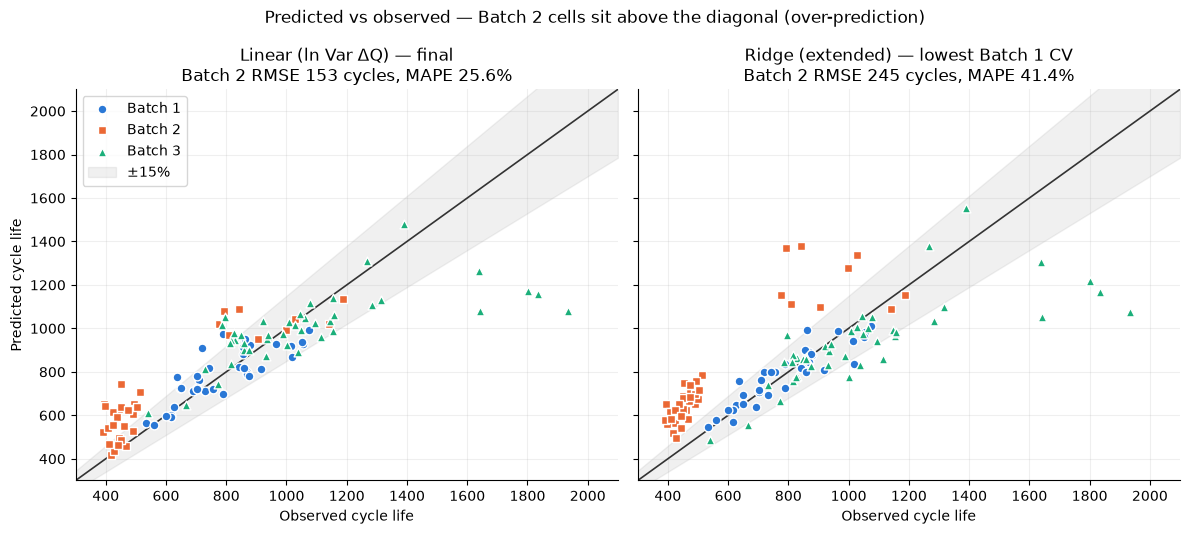

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharex=True, sharey=True)
for ax, name in zip(axes, [FINAL, 'Ridge (extended)']):
    part = pred[pred.model == name]
    for b, (color, marker) in BATCH_STYLE.items():
        p = part[part.batch == b]
        ax.scatter(p.cycle_life, p.predicted, color=color, marker=marker, s=40, edgecolor='white', linewidth=1,
                   label=b, zorder=3)
    lim = np.array([300, 2100])
    ax.plot(lim, lim, color='#333', lw=1.2)
    ax.fill_between(lim, lim * .85, lim * 1.15, color='#888', alpha=.12, label='±15%')
    ax.set_xlim(lim); ax.set_ylim(lim)
    r = perf[(perf.model == name) & (perf.split == 'test')].iloc[0]
    tag = 'final' if name == FINAL else 'lowest Batch 1 CV'
    ax.set_title(f"{name} — {tag}\nBatch 2 RMSE {r.rmse:.0f} cycles, MAPE {r.mape:.1f}%")
    ax.set_xlabel('Observed cycle life')
axes[0].set_ylabel('Predicted cycle life')
axes[0].legend(loc='upper left')
fig.suptitle('Predicted vs observed — Batch 2 cells sit above the diagonal (over-prediction)')
fig.tight_layout()
fig.savefig(FIG / 'm1_predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 논문 대비 GAP (Target − Test, Batch 2)

- **Target**: Severson et al. (2019) Table 1. 같은 모델 형태(`log Var[ΔQ]` 단일 피처 선형)인 논문 **Variance 모델**이 직접 비교 대상입니다. 논문의 최고 primary test 성능(Discharge 모델, 91회 / 13.0%)은 상한 목표로 함께 표시합니다.
- **Test**: 우리 모델의 Batch 2 성능입니다. `GAP = Test − Target`이며, 양수는 목표보다 나쁘다는 뜻입니다.

**비교 조건이 다릅니다.** 이 과제의 Batch 2(2018-02-20)는 논문 124셀에 포함되지 **않은** 배치입니다. 논문의 batch 2는 2017-06-30입니다. 논문은 같은 배치의 셀을 절반씩 나눠 학습·평가했고(학습 41셀), 이 과제는 Batch 1(36셀)만으로 학습해 *다른 배치*를 평가합니다. 따라서 GAP은 **배치를 넘어 일반화할 때의 성능 저하**를 측정합니다. Batch 3는 논문의 secondary test와 같은 배치(2018-04-12)여서 조건이 더 비슷합니다.

In [8]:
fin = gap[gap.model == FINAL].set_index('paper_model')
gap_table = pd.DataFrame({
    'Target RMSE (paper primary)': fin.paper_rmse_primary, 'Test RMSE (ours B2)': fin.ours_rmse_test,
    'GAP RMSE': fin.rmse_gap_test_vs_primary,
    'Target MAPE (paper primary)': fin.paper_mape_primary, 'Test MAPE (ours B2)': fin.ours_mape_test,
    'GAP MAPE (%p)': fin.mape_gap_test_vs_primary,
    'Paper secondary MAPE': fin.paper_mape_secondary, 'Ours B3 MAPE': fin.ours_mape_secondary})
gap_table.index = [f'{FINAL} vs paper {m}' for m in gap_table.index]
gap_table

,Target RMSE (paper primary),Test RMSE (ours B2),GAP RMSE,Target MAPE (paper primary),Test MAPE (ours B2),GAP MAPE (%p),Paper secondary MAPE,Ours B3 MAPE
Linear (ln Var ΔQ) vs paper variance,138,153.0,15.0,14.7,25.6,10.9,11.4,12.1
Linear (ln Var ΔQ) vs paper discharge,91,153.0,62.0,13.0,25.6,12.6,8.6,12.1
Linear (ln Var ΔQ) vs paper full,118,153.0,35.0,14.1,25.6,11.5,10.7,12.1


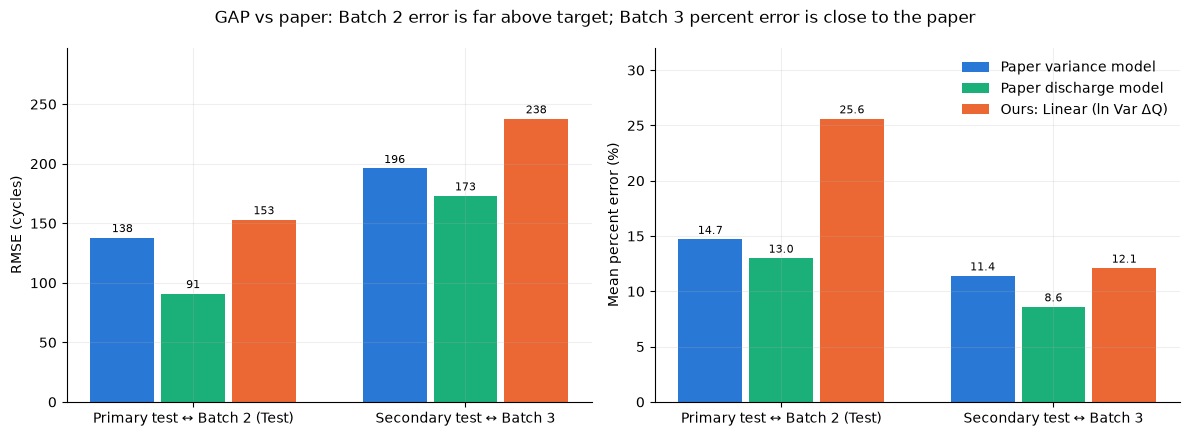

In [9]:
v = gap[(gap.model == FINAL) & (gap.paper_model == 'variance')].iloc[0]
d = gap[(gap.model == FINAL) & (gap.paper_model == 'discharge')].iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, metric, unit in ((axes[0], 'rmse', 'RMSE (cycles)'), (axes[1], 'mape', 'Mean percent error (%)')):
    groups = ['Primary test ↔ Batch 2 (Test)', 'Secondary test ↔ Batch 3']
    paper_v = [v[f'paper_{metric}_primary'], v[f'paper_{metric}_secondary']]
    paper_best = [d[f'paper_{metric}_primary'], d[f'paper_{metric}_secondary']]
    ours = [v[f'ours_{metric}_test'], v[f'ours_{metric}_secondary']]
    x = np.arange(2)
    w = .26
    for i, (label, vals, color) in enumerate((('Paper variance model', paper_v, '#2a78d6'),
                                              ('Paper discharge model', paper_best, '#1baf7a'),
                                              (f'Ours: {FINAL}', ours, '#eb6834'))):
        bars = ax.bar(x + (i - 1) * w, vals, w * .9, color=color, label=label)
        ax.bar_label(bars, labels=[f'{val:.1f}' if metric == 'mape' else f'{val:.0f}' for val in vals],
                     fontsize=8, padding=2)
    ax.set_xticks(x, groups)
    ax.set_ylabel(unit)
    ax.set_ylim(0, max(max(ours), max(paper_v)) * 1.25)
axes[1].legend(loc='upper right', frameon=False)
fig.suptitle('GAP vs paper: Batch 2 error is far above target; Batch 3 percent error is close to the paper')
fig.tight_layout()
fig.savefig(FIG / 'm2_paper_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 오류 분석 — 어디서, 왜 크게 틀리는가

In [10]:
final_test = pred[(pred.model == FINAL) & (pred.split == 'test')].copy()
final_test['structure'] = np.where(final_test.newstructure, 'newstructure', 'original')
final_test.sort_values('abs_pct_error', ascending=False).head(8)[
    ['cell_id', 'policy', 'structure', 'cycle_life', 'predicted', 'residual', 'abs_pct_error', 'ln_dq_variance']].round(1)

,cell_id,policy,structure,cycle_life,predicted,residual,abs_pct_error,ln_dq_variance
173,2_19,5.2C(50%)-4.25C,original,449.0,744.3,295.3,65.8,-8.5
161,2_07,3.6C(9%)-5C,original,393.0,650.7,257.7,65.6,-8.1
170,2_16,3.6C(9%)-5C,original,396.0,643.4,247.4,62.5,-8.1
157,2_03,5.2C(50%)-4.25C,original,424.0,613.9,189.9,44.8,-8.0
182,2_30,5.2C(58%)-4C,original,452.0,639.2,187.2,41.4,-8.1
166,2_12,5.2C(50%)-4.25C,original,449.0,627.1,178.1,39.7,-8.0
177,2_25,4.8C(80%)-4.8C,original,514.0,709.2,195.2,38.0,-8.4
164,2_10,5.6C(26%)-4.5C-newstructure,newstructure,791.0,1080.6,289.6,36.6,-10.0


In [11]:
breakdown[breakdown.model.isin([FINAL, 'Ridge (extended)'])].set_index(['model', 'subgroup'])[
    ['n', 'over_predicted', 'mean_residual', 'rmse', 'mape']].round(1)

n  over_predicted  mean_residual   rmse  mape
model              subgroup                                                                     
Linear (ln Var ΔQ) all                            39              35          119.9  153.0  25.6
                   short life (< 500)             28              27          125.5  147.1  28.4
                   life >= 500                    11               8          105.6  167.2  18.6
                   below train range (< 534)      30              29          128.2  148.6  28.6
                   inside train range (534-1074)   7               6          142.8  182.8  17.8
                   newstructure                    9               6           92.2  166.9  15.5
                   original structure             30              29          128.2  148.6  28.6
Ridge (extended)   all                            39              37          215.9  244.9  41.4
                   short life (< 500)             28              28          194.0  201.9  43.2
                   life >= 500                    11               9          271.6  329.9  36.9
                   below train range (< 534)      30              30          197.2  205.0  43.5
                   inside train range (534-1074)   7               7          369.5  391.6  43.3
                   newstructure                    9               7          278.0  346.0  34.5
                   original structure             30              30          197.2  205.0  43.5

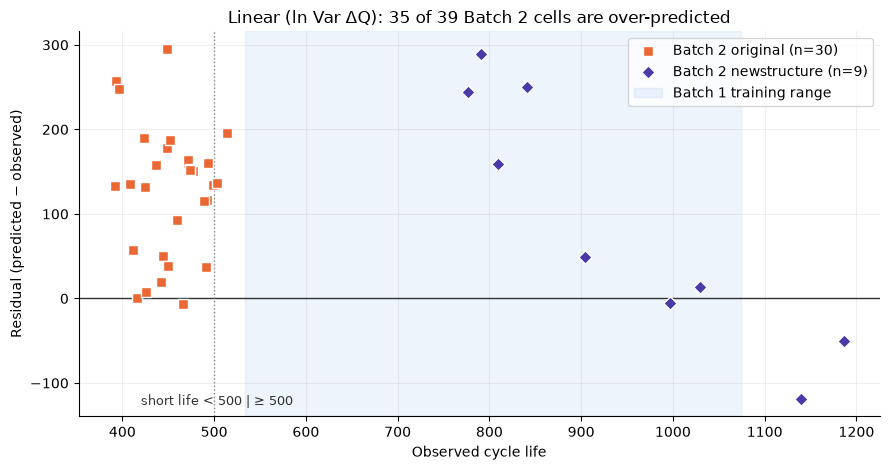

In [12]:
train_life = pred[(pred.model == FINAL) & (pred.split == 'train')].cycle_life
fig, ax = plt.subplots(figsize=(9, 4.8))
for structure, marker, color in (('original', 's', '#eb6834'), ('newstructure', 'D', '#4a3aa7')):
    p = final_test[final_test.structure == structure]
    ax.scatter(p.cycle_life, p.residual, marker=marker, color=color, s=46, edgecolor='white', linewidth=1,
               label=f'Batch 2 {structure} (n={len(p)})', zorder=3)
ax.axhline(0, color='#333', lw=1)
ax.axvspan(train_life.min(), train_life.max(), color='#2a78d6', alpha=.08, label='Batch 1 training range')
ax.axvline(500, color='#888', lw=1, ls=':')
ax.text(503, ax.get_ylim()[0] + 10, 'short life < 500 | ≥ 500', ha='center', va='bottom', fontsize=9, color='#333')
ax.set_xlabel('Observed cycle life')
ax.set_ylabel('Residual (predicted − observed)')
over = int((final_test.residual > 0).sum())
ax.set_title(f'{FINAL}: {over} of {len(final_test)} Batch 2 cells are over-predicted')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'm3_batch2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

### 보고서의 leave-one-batch-out 평가

두 배치로 학습하고 남은 배치를 평가합니다. Batch 2를 빼고 학습해도 Batch 2 오차가 크게 남는다면, 원인은 표본 수가 아니라 **Batch 2 고유의 조건 차이**입니다.

In [13]:
lobo.set_index(['model', 'held_out']).round(1)

n_train   n   rmse    mae  mape
model              held_out                                 
Linear (ln Var ΔQ) Batch 1        83  36  102.6   88.7  11.5
                   Batch 2        80  39  146.3  119.9  22.6
                   Batch 3        75  44  249.2  153.0  12.2

### 개선 가설 검증: 수준 이동만 보정하면 되는가?

새 배치에서 셀 *k*개를 수명 끝까지 시험했다고 가정합니다. 그 셀들의 `log(실제/예측)` 평균으로 보정값 하나만 맞춘 뒤, **나머지 셀**에서 오차를 잽니다(무작위 500회 반복).

,model,calibration_cells,eval_cells,rmse_mean,rmse_p90,mape_mean
0,Linear (ln Var ΔQ),0,39,153.03,153.03,25.61
1,Linear (ln Var ΔQ),3,36,113.89,137.53,14.56
2,Linear (ln Var ΔQ),5,34,108.24,123.67,13.78
3,Linear (ln Var ΔQ),10,29,104.33,119.25,13.22


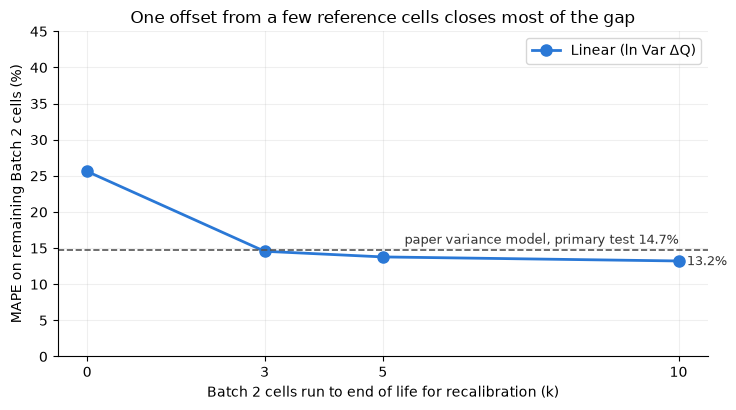

In [14]:
display(recal)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (name, part), (color, marker) in zip(recal.groupby('model', sort=False), (('#2a78d6', 'o'), ('#eb6834', 's'))):
    ax.plot(part.calibration_cells, part.mape_mean, marker=marker, color=color, lw=2, ms=8, label=name)
    last = part.iloc[-1]
    ax.annotate(f'{last.mape_mean:.1f}%', (last.calibration_cells, last.mape_mean), textcoords='offset points',
                xytext=(6, -3), fontsize=9, color='#333')
ax.axhline(14.7, color='#555', ls='--', lw=1.2)
ax.text(10, 15.6, 'paper variance model, primary test 14.7%', ha='right', fontsize=9, color='#333')
ax.set_xlabel('Batch 2 cells run to end of life for recalibration (k)')
ax.set_ylabel('MAPE on remaining Batch 2 cells (%)')
ax.set_xticks([0, 3, 5, 10])
ax.set_ylim(0, 45)
ax.set_title('One offset from a few reference cells closes most of the gap')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'm4_batch2_recalibration.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 결론

**성능과 GAP.** 최종 모델은 보고서의 단일 피처 기준 모델 `Linear (ln Var ΔQ)`입니다(원래 수명 target). Batch 2 Test 결과는 RMSE 153.0회 [128–176], MAE 129.2회, MAPE 25.6% [20–31]입니다. 같은 형태의 논문 Variance 모델(primary test 138회 / 14.7%) 대비 **GAP은 RMSE +15.0회, MAPE +10.9%p**이고, 논문 최고 모델(Discharge, 91회 / 13.0%) 대비로는 +62.0회 / +12.6%p입니다. 논문 secondary test와 같은 배치인 Batch 3에서는 MAPE 12.1%로 논문(11.4%)과 0.7%p 차이입니다. RMSE는 237.7 대 196회로 더 큰데, 1,600회 이상 장수명 셀의 과소예측 때문입니다. Batch 3는 모델 선택에 쓰였으므로 약간 낙관적인 수치입니다.

**보고서 전략의 검증.**
- Batch 1 CV만 보면 Ridge(`ln_dq_variance` + `qd_100` + Qd 기울기)가 최선이었습니다(CV RMSE 68.1 vs 87.6). 하지만 `qd_100`은 Batch 2에서 +2.1 SD 이동해 있어, Ridge는 Batch 2에서 RMSE 244.9회 / MAPE 41.4%로 무너졌습니다. 보고서가 "배치별 상관 방향이 안정적이지 않으므로 검증 오차를 줄일 때만 채택", "배치별 검증 오차가 줄지 않으면 더 단순한 모델"이라고 정한 규칙이 이 실패를 막았습니다.
- 다만 Batch 3에서 Linear와 Ridge의 차이는 근소했습니다(RMSE 237.7 vs 240.4, MAPE 12.1 vs 11.9). 검증 배치 하나로는 판단 근거가 얇습니다.
- Random Forest는 학습 범위(534–1,074회) 밖을 예측하지 못해 Batch 3 장수명 셀에서 크게 틀렸습니다(RMSE 352.7).

**GAP의 원인 — 무작위 오차가 아니라 수준 이동.**
1. Batch 2 39셀 중 35셀이 과대예측됐습니다(평균 잔차 +120회).
2. 02 노트북에서 Batch 2는 같은 ΔQ 값에서도 Batch 1 직선이 예측하는 수명의 **0.76배**에 수명이 끝났습니다(Batch 3는 0.98배).
3. Batch 2를 빼고 Batch 1 + 3(80셀)으로 학습해도 Batch 2 MAPE는 22.6%에 머뭅니다. 표본 수가 아니라 Batch 2 고유의 조건 차이가 원인입니다.
4. 가장 크게 틀린 셀(`2_19`, `2_07`, `2_16`, +63–66%)은 모두 원래 구조의 단수명 셀입니다. 실제 수명은 393–449회인데 ΔQ 분산이 상대적으로 작아 640–745회로 예측됐습니다. Batch 2 원래 구조 30셀의 수명은 392–514회로 몰려 있고, 그 안에서 ΔQ에 따른 순위 구분력이 약합니다(예측–실제 Spearman ρ = 0.38).

**개선 방향.** Batch 2 셀 3개만 수명 끝까지 시험해 보정값 하나를 맞추면, 나머지 셀의 MAPE가 25.6% → 14.6%로 논문 Variance 모델 수준(14.7%)에 도달합니다(10셀이면 13.2%). **피처를 늘리는 것보다 새 배치에 대한 보정이 더 큰 개선 수단**입니다.